# 08 — Australian Electricity Demand Model Experiment

This notebook validates the final experiment pipeline on one dataset before scaling to all datasets on HPC.

Experiment unit:

dataset × model × horizon type × horizon

This notebook records:
- MAE
- RMSE
- sMAPE
- fit time
- inference time
- total runtime
- peak memory usage

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[0]

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)

Project root: /Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from src.data.dataset_loader import load_monash_dataset
from src.experiments.run_model_experiment import run_model_experiment

Importing plotly failed. Interactive plots will not work.


In [3]:
DATASET_KEY = "saugeenday"

MODELS = [
    "naive",
    "seasonal_naive",
    "arima",
    "prophet",
    "lstm",
    "timesfm",
    "ttm",
    "uni2ts",
]

OUTPUT_DIR = Path("results/raw_runs")

In [4]:
bundle = load_monash_dataset(DATASET_KEY)

DEFAULT_HORIZON = int(bundle["resolved_horizon"])

HORIZON_CONFIG = {
    "short": max(1, DEFAULT_HORIZON // 2),
    "long": DEFAULT_HORIZON,
}

dataset_info = {
    "dataset_key": bundle["dataset_key"],
    "domain": bundle["domain"],
    "frequency": bundle["normalized_frequency"],
    "default_horizon": bundle["resolved_horizon"],
    "horizon_strategy": bundle["horizon_strategy"],
    "short_horizon": HORIZON_CONFIG["short"],
    "long_horizon": HORIZON_CONFIG["long"],
    "num_series": len(bundle["records_df"]),
    "num_long_rows": len(bundle["long_df"]),
}

dataset_info

{'dataset_key': 'saugeenday',
 'domain': 'energy',
 'frequency': 'daily',
 'default_horizon': 30,
 'horizon_strategy': 'fallback_capped',
 'short_horizon': 15,
 'long_horizon': 30,
 'num_series': 1,
 'num_long_rows': 23741}

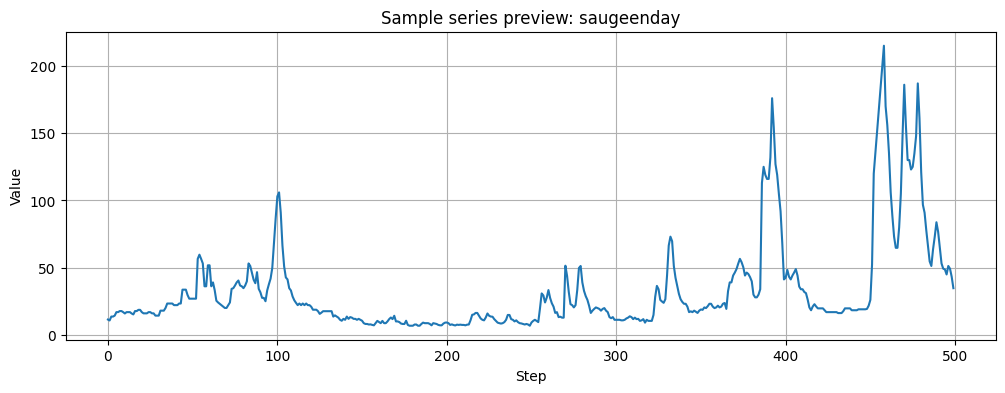

In [5]:
records_df = bundle["records_df"]
first_series = records_df.iloc[0]
values = first_series["series_values"][:500]

plt.figure(figsize=(12, 4))
plt.plot(values)
plt.title(f"Sample series preview: {DATASET_KEY}")
plt.xlabel("Step")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [6]:
run_outputs = []

for horizon_type, horizon in HORIZON_CONFIG.items():
    print(f"\n==============================")
    print(f"Running horizon: {horizon_type} | h={horizon}")
    print(f"==============================")

    for model_name in MODELS:
        print(f"\nRunning model: {model_name}")

        result_df = run_model_experiment(
            dataset_key=DATASET_KEY,
            model_name=model_name,
            horizon=horizon,
            horizon_type=horizon_type,
            experiment_type="baseline",
            output_dir=OUTPUT_DIR,
            series_limit=None,
            save_results=True,
        )

        run_outputs.append(result_df)

print("All runs completed.")


Running horizon: short | h=15

Running model: naive
Saved: results/raw_runs/energy/saugeenday/naive_short_h15_baseline.csv

Running model: seasonal_naive
Saved: results/raw_runs/energy/saugeenday/seasonal_naive_short_h15_baseline.csv

Running model: arima
Saved: results/raw_runs/energy/saugeenday/arima_short_h15_baseline.csv

Running model: prophet


INFO:p-28861:t-8713740480:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-28861:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-28861:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing


Saved: results/raw_runs/energy/saugeenday/prophet_short_h15_baseline.csv

Running model: lstm
Saved: results/raw_runs/energy/saugeenday/lstm_short_h15_baseline.csv

Running model: timesfm


Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 2628.42it/s]
INFO:p-28861:t-8713740480:timesfm_2p5_torch.py:_from_pretrained:Loading checkpoint from local directory: /Users/kunalgurung/.cache/huggingface/hub/models--google--timesfm-2.5-200m-pytorch/snapshots/1d952420fba87f3c6dee4f240de0f1a0fbc790e3
INFO:p-28861:t-8713740480:timesfm_2p5_torch.py:_from_pretrained:Loading checkpoint from: /Users/kunalgurung/.cache/huggingface/hub/models--google--timesfm-2.5-200m-pytorch/snapshots/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/model.safetensors


Compiling model...


...

Saved: results/raw_runs/energy/saugeenday/prophet_long_h30_baseline.csv

Running model: lstm
Saved: results/raw_runs/energy/saugeenday/lstm_long_h30_baseline.csv

Running model: timesfm


INFO:p-28861:t-8713740480:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2


Saved: results/raw_runs/energy/saugeenday/timesfm_long_h30_baseline.csv

Running model: ttm


INFO:p-28861:t-8713740480:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = 512-48-ft-r2.1.
INFO:p-28861:t-8713740480:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 48
Device set to use cpu


Saved: results/raw_runs/energy/saugeenday/ttm_long_h30_baseline.csv

Running model: uni2ts
Saved: results/raw_runs/energy/saugeenday/uni2ts_long_h30_baseline.csv
All runs completed.


In [7]:
combined_df = pd.concat(run_outputs, ignore_index=True)

combined_df.head()

,series_id,dataset_key,domain,frequency,model,horizon,mae,rmse,smape,fit_time_seconds,...,use_continuous_quantile_head,force_flip_invariance,infer_is_positive,fix_quantile_crossing,model_path,normalized_frequency,prefer_longer_context,prefer_l1_loss,context_length,num_samples
0,T1,saugeenday,energy,daily,naive,15,37.800000,58.878949,57.289962,0.000003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T1,saugeenday,energy,daily,seasonal_naive,15,37.666667,55.329293,58.255749,0.000004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,T1,saugeenday,energy,daily,arima,15,38.335568,60.093920,58.171929,0.000003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,T1,saugeenday,energy,daily,prophet,15,39.080013,61.049477,59.942924,0.000637,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,T1,saugeenday,energy,daily,lstm,15,35.202117,56.921434,50.783688,0.000006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
failed_df = combined_df[combined_df["status"] != "success"].copy()

failed_df[["dataset_key", "model", "horizon_type", "series_id", "error_message"]].head(20)

,dataset_key,model,horizon_type,series_id,error_message


In [9]:
accuracy_summary_df = (
    combined_df[combined_df["status"] == "success"]
    .groupby(["dataset_key", "frequency", "model", "horizon_type", "horizon"], as_index=False)
    .agg(
        n_series=("series_id", "count"),
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        smape=("smape", "mean"),
    )
    .sort_values(["horizon_type", "smape"])
    .reset_index(drop=True)
)

accuracy_summary_df

,dataset_key,frequency,model,horizon_type,horizon,n_series,mae,rmse,smape
0,saugeenday,daily,arima,long,30,1,21.071630,41.960155,34.247405
1,saugeenday,daily,naive,long,30,1,21.496667,39.793990,36.031287
2,saugeenday,daily,prophet,long,30,1,22.501317,43.641732,37.955956
3,saugeenday,daily,ttm,long,30,1,23.132256,43.776660,39.403283
4,saugeenday,daily,lstm,long,30,1,26.269580,38.952856,46.132122
5,saugeenday,daily,timesfm,long,30,1,27.172197,48.615942,52.767911
6,saugeenday,daily,uni2ts,long,30,1,28.484110,47.601299,57.001113
7,saugeenday,daily,seasonal_naive,long,30,1,43.666667,51.088022,66.948298
8,saugeenday,daily,lstm,short,15,1,35.202117,56.921434,50.783688
9,saugeenday,daily,uni2ts,short,15,1,37.373881,54.561916,57.274193


In [10]:
best_idx = accuracy_summary_df.groupby("horizon_type")["smape"].idxmin()

best_model_per_horizon_df = accuracy_summary_df.loc[
    best_idx,
    ["horizon_type", "horizon", "model", "smape", "mae", "rmse"]
].reset_index(drop=True)

best_model_per_horizon_df

,horizon_type,horizon,model,smape,mae,rmse
0,long,30,arima,34.247405,21.071630,41.960155
1,short,15,lstm,50.783688,35.202117,56.921434


In [11]:
runtime_summary_df = (
    combined_df[combined_df["status"] == "success"]
    .groupby(["model", "horizon_type", "horizon"], as_index=False)
    .agg(
        avg_fit_time_seconds=("fit_time_seconds", "mean"),
        avg_inference_time_seconds=("inference_time_seconds", "mean"),
        avg_series_total_time_seconds=("series_total_time_seconds", "mean"),
        avg_peak_memory_mb=("peak_memory_mb", "mean"),
        n_series=("series_id", "count"),
    )
    .sort_values(["horizon_type", "avg_series_total_time_seconds"])
    .reset_index(drop=True)
)

runtime_summary_df

,model,horizon_type,horizon,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb,n_series
0,naive,long,30,0.000017,0.000053,0.000079,0.022045,1
1,seasonal_naive,long,30,0.000005,0.000748,0.000760,0.184818,1
2,timesfm,long,30,0.000717,0.616827,0.617553,0.217525,1
3,ttm,long,30,0.000004,1.068701,1.068711,0.876998,1
4,uni2ts,long,30,0.000004,1.166904,1.166916,0.559002,1
5,arima,long,30,0.000004,1.936183,1.936196,26.916751,1
6,prophet,long,30,0.000833,14.568475,14.569327,736.780276,1
7,lstm,long,30,0.000023,84.574712,84.574748,11.205185,1
8,naive,short,15,0.000003,0.000014,0.000021,0.021960,1
9,seasonal_naive,short,15,0.000004,0.000662,0.000673,0.184853,1


In [12]:
horizon_comparison_df = accuracy_summary_df.pivot_table(
    index="model",
    columns="horizon_type",
    values="smape",
    aggfunc="mean",
).reset_index()

horizon_comparison_df["smape_change_long_minus_short"] = (
    horizon_comparison_df["long"] - horizon_comparison_df["short"]
)

horizon_comparison_df = horizon_comparison_df.sort_values("long").reset_index(drop=True)

horizon_comparison_df

horizon_type,model,long,short,smape_change_long_minus_short
0,arima,34.247405,58.171929,-23.924524
1,naive,36.031287,57.289962,-21.258674
2,prophet,37.955956,59.942924,-21.986968
3,ttm,39.403283,59.558430,-20.155147
4,lstm,46.132122,50.783688,-4.651566
5,timesfm,52.767911,66.844632,-14.076721
6,uni2ts,57.001113,57.274193,-0.273080
7,seasonal_naive,66.948298,58.255749,8.692549


In [13]:
def map_model_family(model_name: str) -> str:
    if model_name in {"naive", "seasonal_naive", "arima", "prophet", "lstm"}:
        return "traditional"
    if model_name in {"timesfm", "ttm", "uni2ts"}:
        return "foundation"
    return "other"


accuracy_summary_df["model_family"] = accuracy_summary_df["model"].apply(map_model_family)
runtime_summary_df["model_family"] = runtime_summary_df["model"].apply(map_model_family)

accuracy_summary_df.head()

,dataset_key,frequency,model,horizon_type,horizon,n_series,mae,rmse,smape,model_family
0,saugeenday,daily,arima,long,30,1,21.071630,41.960155,34.247405,traditional
1,saugeenday,daily,naive,long,30,1,21.496667,39.793990,36.031287,traditional
2,saugeenday,daily,prophet,long,30,1,22.501317,43.641732,37.955956,traditional
3,saugeenday,daily,ttm,long,30,1,23.132256,43.776660,39.403283,foundation
4,saugeenday,daily,lstm,long,30,1,26.269580,38.952856,46.132122,traditional


In [14]:
family_accuracy_df = (
    accuracy_summary_df
    .groupby(["model_family", "horizon_type"], as_index=False)
    .agg(
        avg_mae=("mae", "mean"),
        avg_rmse=("rmse", "mean"),
        avg_smape=("smape", "mean"),
    )
    .sort_values(["horizon_type", "avg_smape"])
    .reset_index(drop=True)
)

family_accuracy_df

,model_family,horizon_type,avg_mae,avg_rmse,avg_smape
0,traditional,long,27.001172,43.087351,44.263013
1,foundation,long,26.262854,46.664634,49.724102
2,traditional,short,37.616873,58.454615,56.888850
3,foundation,short,39.291909,59.696834,61.225751


In [15]:
family_runtime_df = (
    runtime_summary_df
    .groupby(["model_family", "horizon_type"], as_index=False)
    .agg(
        avg_fit_time_seconds=("avg_fit_time_seconds", "mean"),
        avg_inference_time_seconds=("avg_inference_time_seconds", "mean"),
        avg_series_total_time_seconds=("avg_series_total_time_seconds", "mean"),
        avg_peak_memory_mb=("avg_peak_memory_mb", "mean"),
    )
    .sort_values(["horizon_type", "avg_series_total_time_seconds"])
    .reset_index(drop=True)
)

family_runtime_df

,model_family,horizon_type,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb
0,foundation,long,0.000242,0.950811,0.951060,0.551175
1,traditional,long,0.000176,20.216034,20.216222,155.021815
2,foundation,short,0.000305,3.194106,3.194433,4.605043
3,traditional,short,0.000131,22.887573,22.887739,154.981160


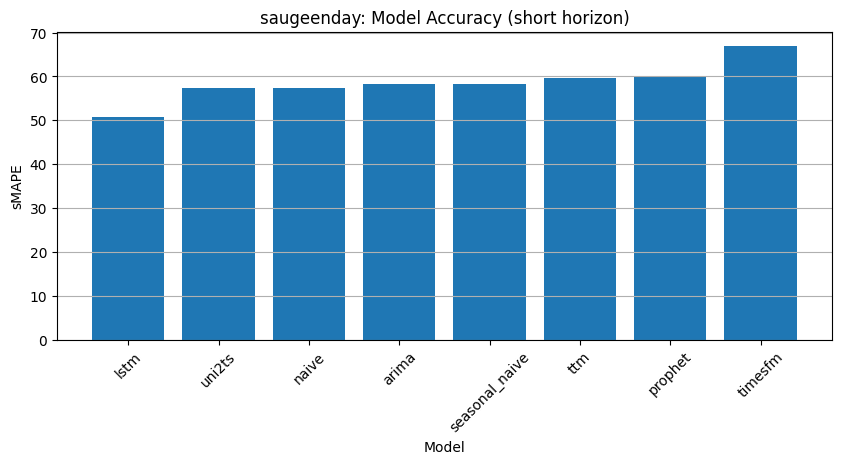

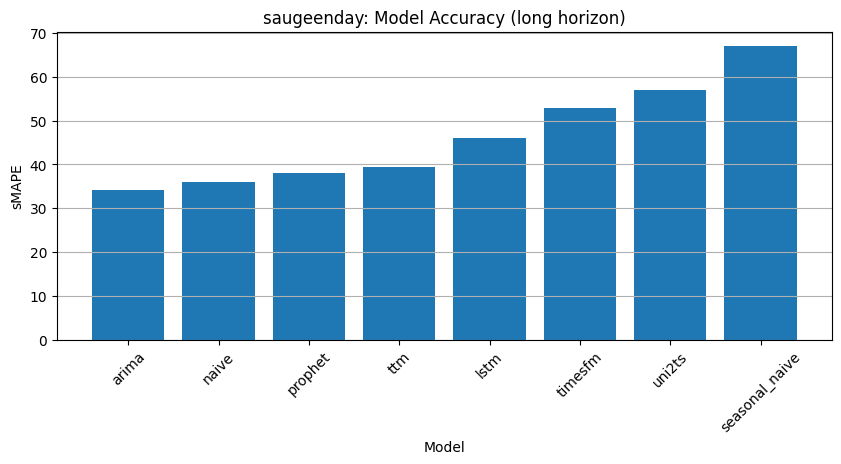

In [16]:
for horizon_type in HORIZON_CONFIG.keys():
    subset = accuracy_summary_df[accuracy_summary_df["horizon_type"] == horizon_type].copy()
    subset = subset.sort_values("smape")

    plt.figure(figsize=(10, 4))
    plt.bar(subset["model"], subset["smape"])
    plt.title(f"{DATASET_KEY}: Model Accuracy ({horizon_type} horizon)")
    plt.xlabel("Model")
    plt.ylabel("sMAPE")
    plt.xticks(rotation=45)
    plt.grid(axis="y")
    plt.show()

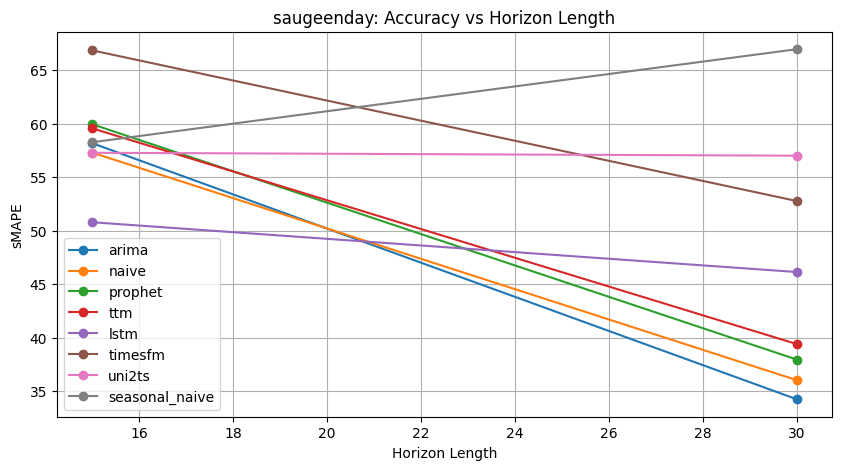

In [17]:
plot_df = accuracy_summary_df.copy()

plt.figure(figsize=(10, 5))

for model_name in plot_df["model"].unique():
    subset = plot_df[plot_df["model"] == model_name].sort_values("horizon")
    plt.plot(subset["horizon"], subset["smape"], marker="o", label=model_name)

plt.title(f"{DATASET_KEY}: Accuracy vs Horizon Length")
plt.xlabel("Horizon Length")
plt.ylabel("sMAPE")
plt.legend()
plt.grid(True)
plt.show()

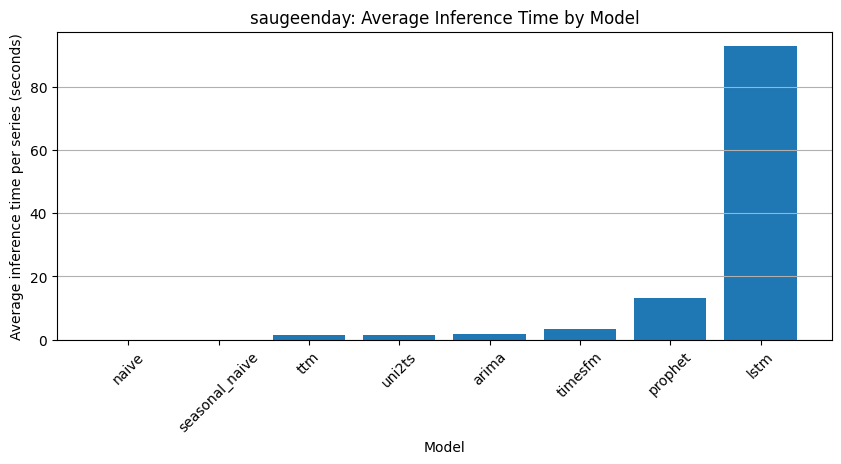

In [18]:
runtime_plot_df = (
    runtime_summary_df
    .groupby("model", as_index=False)["avg_inference_time_seconds"]
    .mean()
    .sort_values("avg_inference_time_seconds")
)

plt.figure(figsize=(10, 4))
plt.bar(runtime_plot_df["model"], runtime_plot_df["avg_inference_time_seconds"])
plt.title(f"{DATASET_KEY}: Average Inference Time by Model")
plt.xlabel("Model")
plt.ylabel("Average inference time per series (seconds)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [19]:
final_dir = Path("results/aggregated")
final_dir.mkdir(parents=True, exist_ok=True)

accuracy_summary_df.to_csv(final_dir / f"{DATASET_KEY}_accuracy_summary.csv", index=False)
best_model_per_horizon_df.to_csv(final_dir / f"{DATASET_KEY}_best_model_per_horizon.csv", index=False)
runtime_summary_df.to_csv(final_dir / f"{DATASET_KEY}_runtime_summary.csv", index=False)
horizon_comparison_df.to_csv(final_dir / f"{DATASET_KEY}_horizon_comparison.csv", index=False)
family_accuracy_df.to_csv(final_dir / f"{DATASET_KEY}_family_accuracy.csv", index=False)
family_runtime_df.to_csv(final_dir / f"{DATASET_KEY}_family_runtime.csv", index=False)

print("Saved outputs to:", final_dir)

Saved outputs to: results/aggregated


## Initial Findings

This single-dataset experiment evaluates all traditional, deep learning, and foundation models on both short and long forecasting horizons.

Key points to inspect:
- Which model has the lowest sMAPE for the short horizon?
- Which model has the lowest sMAPE for the long horizon?
- Does model ranking change as horizon length increases?
- Do foundation models improve or degrade more slowly than traditional models?
- Which models are fastest at inference?
- Which models have the highest memory usage?

This notebook validates the final experiment structure before scaling to all datasets on HPC.

In [27]:
baseline_accuracy_df = accuracy_summary_df.copy()
baseline_runtime_df = runtime_summary_df.copy()

print("Baseline saved.")

Baseline saved.


In [28]:
TUNED_MODEL_PARAMS = {
    "arima": {
        "order": (2, 1, 2),
    },

    "lstm": {
        "hidden_size": 128,
        "num_layers": 2,
        "epochs": 50,
        "learning_rate": 0.0005,
    },

    "prophet": {
        "weekly_seasonality": True,
        "yearly_seasonality": False,
        "daily_seasonality": False,
        "changepoint_prior_scale": 0.03,
        "seasonality_prior_scale": 10.0,
        "seasonality_mode": "additive",
    },

    "timesfm": {
        "max_context": 512,
        "normalize_inputs": True,
        "use_continuous_quantile_head": True,
        "infer_is_positive": True,
        "fix_quantile_crossing": True,
    },

    "ttm": {
        "max_context": 512,
        "prefer_l1_loss": True,
    },

    "uni2ts": {},

    "naive": {},
    "seasonal_naive": {},
}

In [29]:
run_outputs_tuned = []

for horizon_type, horizon in HORIZON_CONFIG.items():
    print(f"\n==============================")
    print(f"TUNED → horizon: {horizon_type} | h={horizon}")
    print(f"==============================")

    for model_name in MODELS:
        print(f"\nRunning tuned model: {model_name}")

        result_df = run_model_experiment(
            dataset_key=DATASET_KEY,
            model_name=model_name,
            horizon=horizon,
            horizon_type=horizon_type,
            experiment_type="tuned",
            output_dir=OUTPUT_DIR,
            model_params=TUNED_MODEL_PARAMS.get(model_name, {}),
            series_limit=None,
            save_results=True,
        )

        run_outputs_tuned.append(result_df)

print("All tuned runs completed.")


TUNED → horizon: short | h=15

Running tuned model: naive
Saved: results/raw_runs/energy/saugeenday/naive_short_h15_tuned.csv

Running tuned model: seasonal_naive
Saved: results/raw_runs/energy/saugeenday/seasonal_naive_short_h15_tuned.csv

Running tuned model: arima
Saved: results/raw_runs/energy/saugeenday/arima_short_h15_tuned.csv

Running tuned model: prophet


INFO:p-28861:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-28861:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing


Saved: results/raw_runs/energy/saugeenday/prophet_short_h15_tuned.csv

Running tuned model: lstm
Saved: results/raw_runs/energy/saugeenday/lstm_short_h15_tuned.csv

Running tuned model: timesfm
Saved: results/raw_runs/energy/saugeenday/timesfm_short_h15_tuned.csv

Running tuned model: ttm


INFO:p-28861:t-8713740480:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-28861:t-8713740480:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = 512-48-ft-l1-r2.1.
INFO:p-28861:t-8713740480:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 48
Device set to use cpu


Saved: results/raw_runs/energy/saugeenday/ttm_short_h15_tuned.csv

Running tuned model: uni2ts
Saved: results/raw_runs/energy/saugeenday/uni2ts_short_h15_tuned.csv

TUNED → horizon: long | h=30

Running tuned model: naive
Saved: results/raw_runs/energy/saugeenday/naive_long_h30_tuned.csv

Running tuned model: seasonal_naive
Saved: results/raw_runs/energy/saugeenday/seasonal_naive_long_h30_tuned.csv

Running tuned model: arima
Saved: results/raw_runs/energy/saugeenday/arima_long_h30_tuned.csv

Running tuned model: prophet


...

Saved: results/raw_runs/energy/saugeenday/prophet_long_h30_tuned.csv

Running tuned model: lstm
Saved: results/raw_runs/energy/saugeenday/lstm_long_h30_tuned.csv

Running tuned model: timesfm


INFO:p-28861:t-8713740480:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2


Saved: results/raw_runs/energy/saugeenday/timesfm_long_h30_tuned.csv

Running tuned model: ttm


INFO:p-28861:t-8713740480:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = 512-48-ft-l1-r2.1.
INFO:p-28861:t-8713740480:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 48
Device set to use cpu


Saved: results/raw_runs/energy/saugeenday/ttm_long_h30_tuned.csv

Running tuned model: uni2ts
Saved: results/raw_runs/energy/saugeenday/uni2ts_long_h30_tuned.csv
All tuned runs completed.


In [30]:
combined_tuned_df = pd.concat(run_outputs_tuned, ignore_index=True)

combined_tuned_df.head()

,series_id,dataset_key,domain,frequency,model,horizon,mae,rmse,smape,fit_time_seconds,...,use_continuous_quantile_head,force_flip_invariance,infer_is_positive,fix_quantile_crossing,model_path,normalized_frequency,prefer_longer_context,prefer_l1_loss,context_length,num_samples
0,T1,saugeenday,energy,daily,naive,15,37.800000,58.878949,57.289962,0.000006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T1,saugeenday,energy,daily,seasonal_naive,15,37.666667,55.329293,58.255749,0.000004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,T1,saugeenday,energy,daily,arima,15,36.754517,58.078207,54.674010,0.000005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,T1,saugeenday,energy,daily,prophet,15,37.857899,59.178294,57.283778,0.000396,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,T1,saugeenday,energy,daily,lstm,15,39.719243,60.339558,62.210136,0.000007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
accuracy_tuned_df = (
    combined_tuned_df[combined_tuned_df["status"] == "success"]
    .groupby(["dataset_key", "frequency", "model", "horizon_type", "horizon"], as_index=False)
    .agg(
        n_series=("series_id", "count"),
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        smape=("smape", "mean"),
    )
    .sort_values(["horizon_type", "smape"])
    .reset_index(drop=True)
)

accuracy_tuned_df

,dataset_key,frequency,model,horizon_type,horizon,n_series,mae,rmse,smape
0,saugeenday,daily,arima,long,30,1,20.856527,41.114839,33.949020
1,saugeenday,daily,prophet,long,30,1,21.214028,42.243223,34.546633
2,saugeenday,daily,naive,long,30,1,21.496667,39.793990,36.031287
3,saugeenday,daily,ttm,long,30,1,24.433606,46.523356,43.000036
4,saugeenday,daily,lstm,long,30,1,28.638903,38.440724,49.187159
5,saugeenday,daily,timesfm,long,30,1,27.172197,48.615942,52.767911
6,saugeenday,daily,uni2ts,long,30,1,27.804803,46.875618,56.969453
7,saugeenday,daily,seasonal_naive,long,30,1,43.666667,51.088022,66.948298
8,saugeenday,daily,uni2ts,short,15,1,34.827594,52.195263,52.343573
9,saugeenday,daily,arima,short,15,1,36.754517,58.078207,54.674010


In [32]:
compare_df = baseline_accuracy_df.merge(
    accuracy_tuned_df,
    on=["model", "horizon_type"],
    suffixes=("_baseline", "_tuned"),
)

compare_df["smape_improvement"] = (
    compare_df["smape_baseline"] - compare_df["smape_tuned"]
)

compare_df = compare_df.sort_values(
    ["horizon_type", "smape_improvement"],
    ascending=[True, False]
)

compare_df

,dataset_key_baseline,frequency_baseline,model,horizon_type,horizon_baseline,n_series_baseline,mae_baseline,rmse_baseline,smape_baseline,model_family,dataset_key_tuned,frequency_tuned,horizon_tuned,n_series_tuned,mae_tuned,rmse_tuned,smape_tuned,smape_improvement
2,saugeenday,daily,prophet,long,30,1,22.501317,43.641732,37.955956,traditional,saugeenday,daily,30,1,21.214028,42.243223,34.546633,3.409323
0,saugeenday,daily,arima,long,30,1,21.071630,41.960155,34.247405,traditional,saugeenday,daily,30,1,20.856527,41.114839,33.949020,0.298385
6,saugeenday,daily,uni2ts,long,30,1,28.484110,47.601299,57.001113,foundation,saugeenday,daily,30,1,27.804803,46.875618,56.969453,0.031660
1,saugeenday,daily,naive,long,30,1,21.496667,39.793990,36.031287,traditional,saugeenday,daily,30,1,21.496667,39.793990,36.031287,0.000000
5,saugeenday,daily,timesfm,long,30,1,27.172197,48.615942,52.767911,foundation,saugeenday,daily,30,1,27.172197,48.615942,52.767911,0.000000
7,saugeenday,daily,seasonal_naive,long,30,1,43.666667,51.088022,66.948298,traditional,saugeenday,daily,30,1,43.666667,51.088022,66.948298,0.000000
4,saugeenday,daily,lstm,long,30,1,26.269580,38.952856,46.132122,traditional,saugeenday,daily,30,1,28.638903,38.440724,49.187159,-3.055037
3,saugeenday,daily,ttm,long,30,1,23.132256,43.776660,39.403283,foundation,saugeenday,daily,30,1,24.433606,46.523356,43.000036,-3.596753
9,saugeenday,daily,uni2ts,short,15,1,37.373881,54.561916,57.274193,foundation,saugeenday,daily,15,1,34.827594,52.195263,52.343573,4.930619
11,saugeenday,daily,arima,short,15,1,38.335568,60.093920,58.171929,traditional,saugeenday,daily,15,1,36.754517,58.078207,54.674010,3.497919


In [33]:
runtime_tuned_df = (
    combined_tuned_df[combined_tuned_df["status"] == "success"]
    .groupby(["model", "horizon_type", "horizon"], as_index=False)
    .agg(
        avg_fit_time_seconds=("fit_time_seconds", "mean"),
        avg_inference_time_seconds=("inference_time_seconds", "mean"),
        avg_series_total_time_seconds=("series_total_time_seconds", "mean"),
        avg_peak_memory_mb=("peak_memory_mb", "mean"),
        n_series=("series_id", "count"),
    )
    .sort_values(["horizon_type", "avg_series_total_time_seconds"])
    .reset_index(drop=True)
)

runtime_tuned_df

,model,horizon_type,horizon,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb,n_series
0,naive,long,30,0.000004,0.000044,0.000055,0.021507,1
1,seasonal_naive,long,30,0.000005,0.000891,0.000903,0.184818,1
2,timesfm,long,30,0.000497,0.477326,0.477828,0.212768,1
3,uni2ts,long,30,0.000002,1.158365,1.158373,0.564089,1
4,ttm,long,30,0.000021,1.214043,1.214071,0.870652,1
5,arima,long,30,0.000003,3.262695,3.262705,67.377350,1
6,prophet,long,30,0.000554,7.735879,7.736440,732.599627,1
7,lstm,long,30,0.000005,666.820407,666.820426,11.209941,1
8,naive,short,15,0.000006,0.000030,0.000040,0.022148,1
9,seasonal_naive,short,15,0.000004,0.000674,0.000685,0.184830,1


In [34]:
runtime_compare_df = baseline_runtime_df.merge(
    runtime_tuned_df,
    on=["model", "horizon_type", "horizon"],
    suffixes=("_baseline", "_tuned"),
)

runtime_compare_df["inference_time_change"] = (
    runtime_compare_df["avg_inference_time_seconds_tuned"]
    - runtime_compare_df["avg_inference_time_seconds_baseline"]
)

runtime_compare_df["memory_change_mb"] = (
    runtime_compare_df["avg_peak_memory_mb_tuned"]
    - runtime_compare_df["avg_peak_memory_mb_baseline"]
)

runtime_compare_df

,model,horizon_type,horizon,avg_fit_time_seconds_baseline,avg_inference_time_seconds_baseline,avg_series_total_time_seconds_baseline,avg_peak_memory_mb_baseline,n_series_baseline,model_family,avg_fit_time_seconds_tuned,avg_inference_time_seconds_tuned,avg_series_total_time_seconds_tuned,avg_peak_memory_mb_tuned,n_series_tuned,inference_time_change,memory_change_mb
0,naive,long,30,0.000017,0.000053,0.000079,0.022045,1,traditional,0.000004,0.000044,0.000055,0.021507,1,-0.000009,-0.000538
1,seasonal_naive,long,30,0.000005,0.000748,0.000760,0.184818,1,traditional,0.000005,0.000891,0.000903,0.184818,1,0.000143,0.000000
2,timesfm,long,30,0.000717,0.616827,0.617553,0.217525,1,foundation,0.000497,0.477326,0.477828,0.212768,1,-0.139501,-0.004758
3,ttm,long,30,0.000004,1.068701,1.068711,0.876998,1,foundation,0.000021,1.214043,1.214071,0.870652,1,0.145342,-0.006346
4,uni2ts,long,30,0.000004,1.166904,1.166916,0.559002,1,foundation,0.000002,1.158365,1.158373,0.564089,1,-0.008539,0.005087
5,arima,long,30,0.000004,1.936183,1.936196,26.916751,1,traditional,0.000003,3.262695,3.262705,67.377350,1,1.326512,40.460599
6,prophet,long,30,0.000833,14.568475,14.569327,736.780276,1,traditional,0.000554,7.735879,7.736440,732.599627,1,-6.832596,-4.180649
7,lstm,long,30,0.000023,84.574712,84.574748,11.205185,1,traditional,0.000005,666.820407,666.820426,11.209941,1,582.245695,0.004756
8,naive,short,15,0.000003,0.000014,0.000021,0.021960,1,traditional,0.000006,0.000030,0.000040,0.022148,1,0.000016,0.000188
9,seasonal_naive,short,15,0.000004,0.000662,0.000673,0.184853,1,traditional,0.000004,0.000674,0.000685,0.184830,1,0.000012,-0.000023


In [35]:
runtime_tuned_df.to_csv(final_dir / f"{DATASET_KEY}_runtime_tuned.csv", index=False)
runtime_compare_df.to_csv(final_dir / f"{DATASET_KEY}_runtime_compare_baseline_vs_tuned.csv", index=False)

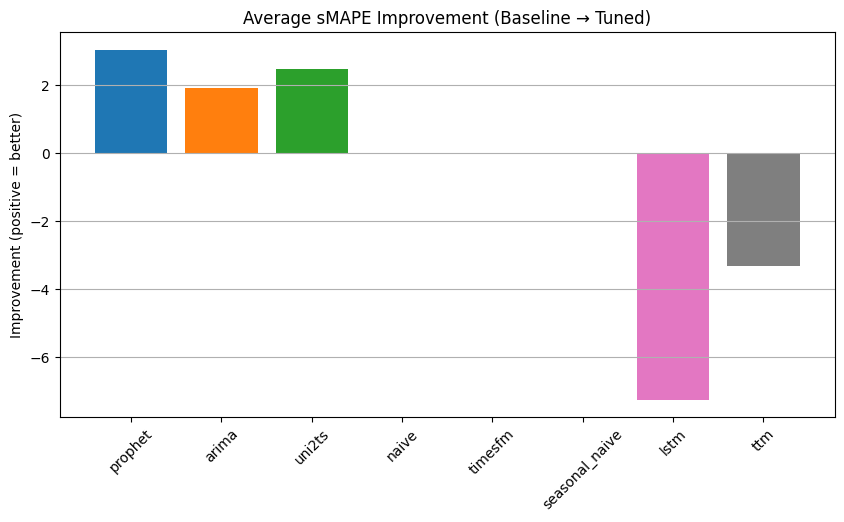

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for model in compare_df["model"].unique():
    subset = compare_df[compare_df["model"] == model]
    plt.bar(model, subset["smape_improvement"].mean())

plt.title("Average sMAPE Improvement (Baseline → Tuned)")
plt.ylabel("Improvement (positive = better)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()